In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

In [2]:
cluster_infos = []
years = range(2015,2025)
borders_path = r"C:\Users\darja\Complexity72h\complexity72_2026\ne_110m_admin_0_countries.gpkg"

for year in years:
    if year!= 2017: 
        # ── 1. Cluster summary (your data) ───────────────────────────────────────────
        clusters = pd.read_csv(
            f"C:\\Users\\darja\\Complexity72h\\complexity72_2026\\clustering\\barycenter\\kmeans_cluster_barycenters_k5_{year}.csv"
    )
        clusters["year"] = year
        cluster_infos.append(clusters)

#Normalize across all years for consistent color mapping
all_clusters = pd.concat(cluster_infos, ignore_index=True)

all_clusters_normalized = all_clusters.copy()

vars_to_encode = ["emission", "growth_rate", "gosif"]

for col in vars_to_encode:
    col_min, col_max = all_clusters_normalized[col].min(), all_clusters_normalized[col].max()
    scale = col_max - col_min
    if scale == 0:
        all_clusters_normalized[col] = 0.5
    else:
        all_clusters_normalized[col] = (all_clusters_normalized[col] - col_min) / scale

#all_clusters_normalized

Simple ranking from diff between emission and bio

In [ ]:
""" cluster_infos = []
years = range(2015,2025)
borders_path = r"C:/Users/darja/Complexity72h/complexity72_2026/ne_110m_admin_0_countries.gpkg"

ranking_diff_map = {1:'Strongly GOSIF', 2:'Moderately GOSIF', 3:'No emissions', 4:'Moderately Emission', 5:'Strongly Emission'}

for year in years:
    if year!= 2017: 
        # ── 1. Cluster summary (your data) ───────────────────────────────────────────
        clusters = pd.read_csv(
            f"C://Users//darja//Complexity72h//complexity72_2026//clustering//barycenter//kmeans_cluster_barycenters_k5_{year}.csv"
    )
        clusters['emission_norm'] = (clusters['emission'] - clusters['emission'].min()) / (clusters['emission'].max() - clusters['emission'].min())
        clusters['gosif_norm'] = (clusters['gosif'] - clusters['gosif'].min()) / (clusters['gosif'].max() - clusters['gosif'].min())
        clusters['growth_rate_norm'] = (clusters['growth_rate'] - clusters['growth_rate'].min()) / (clusters['growth_rate'].max() - clusters['growth_rate'].min())

        clusters['diff'] = clusters['gosif_norm'] / clusters['emission_norm']

        no_emission_condition = (clusters['emission_norm'] == 0) & (clusters['gosif_norm'] == 0)

        # 2. Sort by 'diff' ascending so the order is ready for ranking
        clusters.sort_values(by='diff', ascending=True, inplace=True)

        # 3. Create a temporary ranking for the rows that are NOT the special cluster
        # This counts 1, 2, 3, 4... for only the valid rows
        non_special_rows = ~no_emission_condition
        clusters.loc[non_special_rows, 'ranked_cluster'] = range(1, non_special_rows.sum() + 1)

        # 4. Shift any ranks that are >= 3 up by 1 to make room for cluster 3
        clusters.loc[clusters['ranked_cluster'] >= 3, 'ranked_cluster'] += 1

        # 5. Explicitly assign 3 to your special condition row(s)
        clusters.loc[no_emission_condition, 'ranked_cluster'] = 3

        # 6. Ensure the data type is integer (optional but recommended)
        clusters['ranked_cluster'] = clusters['ranked_cluster'].astype(int)
        
        clusters['ranked_cluster'] = clusters['ranked_cluster'].map(ranking_diff_map)
        clusters["year"] = year

        cluster_infos.append(clusters)

cluster_infos = pd.concat(cluster_infos, ignore_index=True)
cluster_infos.to_csv(r"C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv", index=False)

cluster_infos"
"""

,cluster,point_count,emission,growth_rate,gosif,emission_norm,gosif_norm,growth_rate_norm,diff,ranked_cluster,year
0,5,4320,35811.307227,2.756427,0.088911,0.624136,0.303175,0.569246,0.485752,Strongly GOSIF,2015
1,2,1830,57376.597000,2.033845,0.191053,1.000000,0.653116,0.000000,0.653116,Moderately GOSIF,2015
2,3,6715,3152.917789,2.342195,0.019603,0.054929,0.065727,0.242916,1.196583,Moderately Emission,2015
3,4,1778,13802.777063,3.303213,0.292302,0.240546,1.000000,1.000000,4.157203,Strongly Emission,2015
4,1,6894,1.377713,2.125667,0.000419,0.000000,0.000000,0.072337,NaN,No emissions,2015
5,3,4208,11482.824794,3.161038,0.022609,0.196197,0.075539,0.713959,0.385014,Strongly GOSIF,2016
6,5,3334,58524.902355,3.064399,0.155366,1.000000,0.530623,0.478578,0.530623,Moderately GOSIF,2016
7,4,1960,26638.652115,3.278476,0.292293,0.455163,1.000000,1.000000,2.197014,Moderately Emission,2016
8,2,5158,1973.029703,2.898826,0.043738,0.033705,0.147968,0.075295,4.390131,Strongly Emission,2016
9,1,6877,0.489089,2.867912,0.000573,0.000000,0.000000,0.000000,NaN,No emissions,2016


In [23]:
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

# ── 0. Setup ──────────────────────────────────────────────────────────────────
# Assume you have a dict of dataframes, one per year:
# dfs = {2010: df_2010, 2011: df_2011, ...}
# Each df has columns: lat, lon, cluster, emission, gosif, growth_rate
years = range(2015, 2025)

full_df = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv")
dfs = {year: full_df[full_df[f'year'] == year] for year in years}


FEATURES = ['emission', 'gosif']  # as you said, drop growth_rate

def get_centroids(df, features=FEATURES, n_clusters=5):
    """Compute cluster centroids on chosen features."""
    return (
        df.groupby('cluster')[features]
        .mean()
        .sort_index()  # ensure consistent row order 1..5
    )

# ── 1. Compute centroids per year ─────────────────────────────────────────────
years = sorted(dfs.keys())
centroids = {yr: get_centroids(dfs[yr]) for yr in years}

# ── 2. Build label mapping relative to reference year ────────────────────────
reference_year = years[0]
ref_centroids = centroids[reference_year].values  # shape (5, 2)

label_mappings = {reference_year: {i+1: i+1 for i in range(5)}}  # identity

for yr in years[1:]:
    yr_centroids = centroids[yr].values  # shape (5, 2)

    # Cost matrix: pairwise distances between ref centroids and this year's
    cost_matrix = cdist(ref_centroids, yr_centroids, metric='euclidean')

    # Hungarian algorithm: finds optimal 1-to-1 assignment
    ref_idx, yr_idx = linear_sum_assignment(cost_matrix)

    # ref cluster (ref_idx+1) should be renamed to match yr cluster (yr_idx+1)
    # We want: yr_label → ref_label
    mapping = {}
    for r, y in zip(ref_idx, yr_idx):
        yr_label  = y + 1   # original label in this year
        ref_label = r + 1   # what it should be renamed to
        mapping[yr_label] = ref_label

    label_mappings[yr] = mapping
    print(f"{yr}: {mapping}")

# ── 3. Apply remapping to each dataframe ─────────────────────────────────────
dfs_aligned = {}
for yr in years:
    df = dfs[yr].copy()
    df['cluster_aligned'] = df['cluster'].map(label_mappings[yr])
    dfs_aligned[yr] = df
    dfs_aligned[yr].drop(columns=['ranked_cluster'], inplace=True)

2016: {np.int64(1): np.int64(1), np.int64(5): np.int64(2), np.int64(2): np.int64(3), np.int64(3): np.int64(4), np.int64(4): np.int64(5)}
2017: {}
2018: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(2): np.int64(5)}
2019: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(3): np.int64(5)}
2020: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(3): np.int64(5)}
2021: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3), np.int64(5): np.int64(4), np.int64(4): np.int64(5)}
2022: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3), np.int64(5): np.int64(4), np.int64(4): np.int64(5)}
2023: {np.int64(1): np.int64(1), np.int64(5): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(2): np.int64(5)}
2024: {np.int64(1): np.int64(1),

In [33]:
dfs[2015].head()

,cluster,point_count,emission,growth_rate,gosif,emission_norm,gosif_norm,growth_rate_norm,diff,ranked_cluster,year
0,5,4320,35811.307227,2.756427,0.088911,0.624136,0.303175,0.569246,0.485752,Strongly GOSIF,2015
1,2,1830,57376.597000,2.033845,0.191053,1.000000,0.653116,0.000000,0.653116,Moderately GOSIF,2015
2,3,6715,3152.917789,2.342195,0.019603,0.054929,0.065727,0.242916,1.196583,Moderately Emission,2015
3,4,1778,13802.777063,3.303213,0.292302,0.240546,1.000000,1.000000,4.157203,Strongly Emission,2015
4,1,6894,1.377713,2.125667,0.000419,0.000000,0.000000,0.072337,NaN,No emissions,2015


Global template centroids:
                    emission_norm  gosif_norm
template_cluster_1       0.000000    0.000000
template_cluster_2       0.633882    0.398192
template_cluster_3       0.486232    0.214291
template_cluster_4       0.401251    0.879918
template_cluster_5       0.362711    0.333063

Label remappings per year:
  2015: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(5): np.int64(3), np.int64(4): np.int64(4), np.int64(3): np.int64(5)}
  2016: {np.int64(1): np.int64(1), np.int64(5): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(2): np.int64(5)}
  2018: {np.int64(1): np.int64(1), np.int64(3): np.int64(2), np.int64(2): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}
  2019: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5)}
  2020: {np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), 

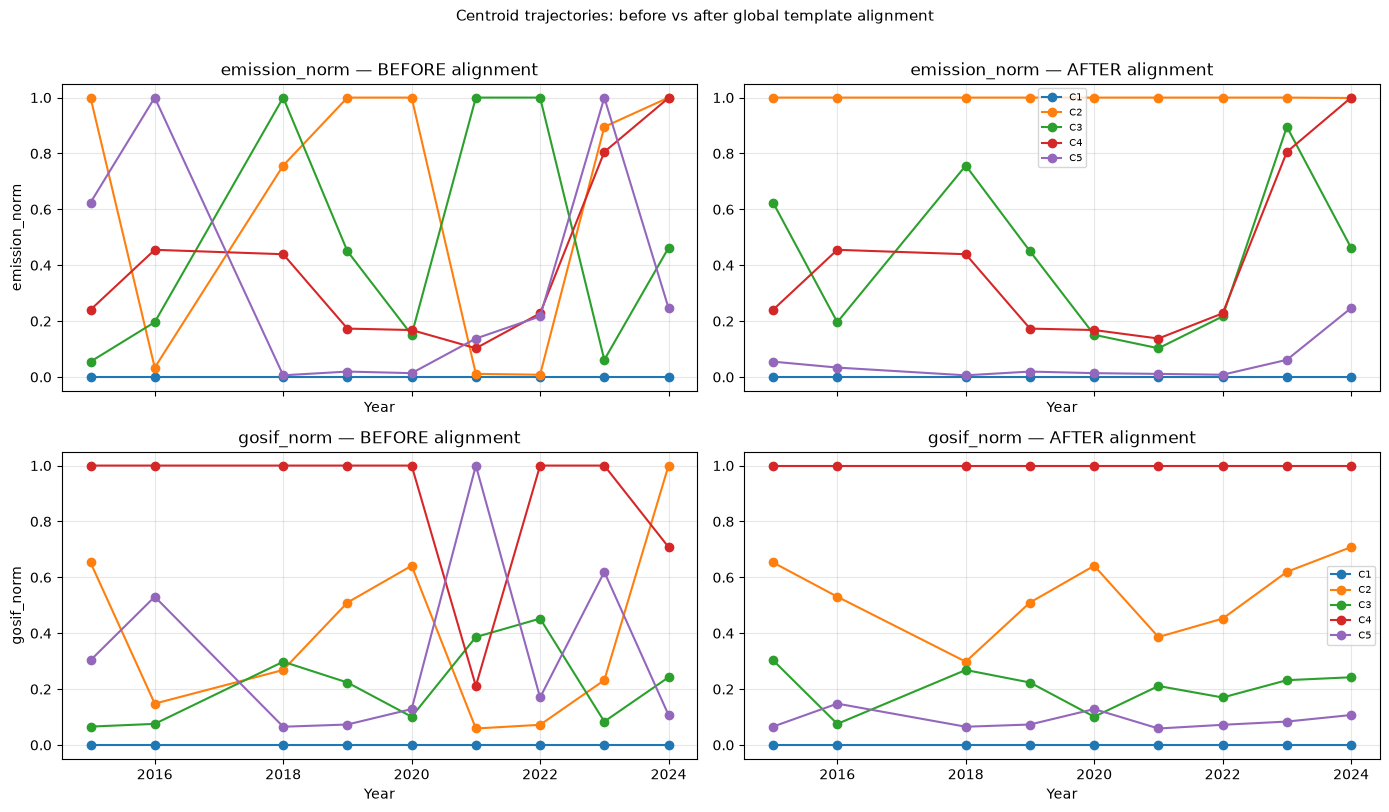

In [37]:
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

# ── 0. Config ─────────────────────────────────────────────────────────────────
FEATURES    = ['emission_norm', 'gosif_norm']   # growth_rate excluded
N_CLUSTERS  = 5

# ── 1. Load your data ─────────────────────────────────────────────────────────
# Expects a dict: {year (int): pd.DataFrame}
# Each df must have columns: lat, lon, cluster, emission, gosif, growth_rate
#
# Example loader — adapt to your actual file structure:
#
# import glob, os
# dfs = {}
# for path in sorted(glob.glob("data/year_*.csv")):
#     yr = int(os.path.basename(path).split("_")[1].split(".")[0])
#     dfs[yr] = pd.read_csv(path)

# dfs = { 2010: df_2010, 2011: df_2011, ... }   ← your dict here

years = [2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  # exclude 2017

full_df = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_cluster_all_years.csv")
dfs = {year: full_df[full_df[f'year'] == year] for year in years}

# ── 2. Compute per-year centroids ─────────────────────────────────────────────
def get_centroids(df: pd.DataFrame) -> pd.DataFrame:
    """
    Returns a (N_CLUSTERS x len(FEATURES)) DataFrame
    indexed by original cluster label (1..N_CLUSTERS).
    """
    c = df.groupby('cluster')[FEATURES].mean().sort_index()
    assert len(c) == N_CLUSTERS, \
        f"Expected {N_CLUSTERS} clusters, got {len(c)}"
    return c

centroids_raw = {yr: get_centroids(dfs[yr]) for yr in years}

# ── 3. Build global template (mean centroid across all years) ─────────────────
# Shape: (n_years, N_CLUSTERS, n_features)
all_centroid_arrays = np.stack([centroids_raw[yr].values for yr in years])

# Mean over years → (N_CLUSTERS, n_features)
# NOTE: this assumes cluster labels are already *roughly* consistent across years
# (which they may not be — see comment below). If your data is very inconsistent
# pre-alignment, consider bootstrapping: run the alignment iteratively 2-3 times,
# each time recomputing the template from the newly aligned centroids.
global_template = all_centroid_arrays.mean(axis=0)

print("Global template centroids:")
print(pd.DataFrame(global_template, columns=FEATURES,
                   index=[f'template_cluster_{i+1}' for i in range(N_CLUSTERS)]))

# ── 4. Align each year to the global template via Hungarian algorithm ──────────
def align_to_template(yr_centroids: np.ndarray,
                      template: np.ndarray) -> dict:
    """
    Returns mapping: {original_yr_label -> aligned_label}
    Minimises total Euclidean distance between matched centroid pairs.
    """
    cost_matrix = cdist(template, yr_centroids, metric='euclidean')  # (N, N)
    tmpl_idx, yr_idx = linear_sum_assignment(cost_matrix)
    # tmpl_idx[i] should be renamed to match yr cluster yr_idx[i]
    return {yr_idx[i] + 1: tmpl_idx[i] + 1 for i in range(N_CLUSTERS)}

label_mappings = {}
for yr in years:
    mapping = align_to_template(centroids_raw[yr].values, global_template)
    label_mappings[yr] = mapping

print("\nLabel remappings per year:")
for yr, m in label_mappings.items():
    print(f"  {yr}: {m}")

# ── 5. Apply remapping to each dataframe ──────────────────────────────────────
dfs_aligned = {}
for yr in years:
    df = dfs[yr].copy()
    df['cluster_aligned'] = df['cluster'].map(label_mappings[yr])
    dfs_aligned[yr] = df


# Iterative refinement (2-3 rounds is usually enough)
N_ITER = 10

for iteration in range(N_ITER):
    # Recompute template from currently aligned centroids
    aligned_centroid_arrays = np.stack([
        dfs_aligned[yr].groupby('cluster_aligned')[FEATURES].mean()
                        .sort_index().values
        for yr in years
    ])
    global_template = aligned_centroid_arrays.mean(axis=0)

    # Re-align all years to updated template
    for yr in years:
        mapping = align_to_template(
            centroids_raw[yr].values, global_template
        )
        label_mappings[yr] = mapping
        dfs_aligned[yr]['cluster_aligned'] = dfs_aligned[yr]['cluster'].map(mapping)

    print(f"Iteration {iteration+1} done.")


# ── 6. Sanity check: plot centroid trajectories before vs after ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for feat_idx, feat in enumerate(FEATURES):
    ax_before = axes[feat_idx * 2]
    ax_after  = axes[feat_idx * 2 + 1]

    for c in range(1, N_CLUSTERS + 1):
        # Before: raw centroid of whatever cluster label 'c' happened to be
        before_vals = [centroids_raw[yr].loc[c, feat] for yr in years]

        # After: centroid of the *aligned* cluster 'c'
        after_vals = []
        for yr in years:
            aligned_df = dfs_aligned[yr]
            val = aligned_df[aligned_df['cluster_aligned'] == c][feat].mean()
            after_vals.append(val)

        ax_before.plot(years, before_vals, marker='o', label=f'C{c}')
        ax_after.plot(years,  after_vals,  marker='o', label=f'C{c}')

    ax_before.set_title(f'{feat} — BEFORE alignment')
    ax_after.set_title(f'{feat} — AFTER alignment')
    ax_before.set_ylabel(feat)
    ax_after.legend(fontsize=7)

for ax in axes:
    ax.set_xlabel('Year')
    ax.grid(True, alpha=0.3)

plt.suptitle('Centroid trajectories: before vs after global template alignment',
             fontsize=11, y=1.01)
plt.tight_layout()
#plt.savefig('alignment_sanity_check.pdf', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
all_points = pd.read_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_classified_points_all_years.csv")
all_points

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,kmeans_cluster_2023,kmeans_cluster_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,1,1
1,-178.5,-89.5,1,1,1,1,1,1,1,1,1,1
2,-177.5,-89.5,1,1,1,1,1,1,1,1,1,1
3,-176.5,-89.5,1,1,1,1,1,1,1,1,1,1
4,-175.5,-89.5,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
21532,-31.5,83.5,3,2,2,5,5,5,2,2,3,1
21533,-30.5,83.5,3,2,2,5,5,5,2,2,3,1
21534,-29.5,83.5,3,2,2,5,5,5,2,2,3,1
21535,-28.5,83.5,3,2,2,5,5,5,2,2,3,1


In [44]:
all_points_aligned = all_points.copy()

years = sorted(dfs_aligned.keys())

for year in years:
    old_col = f"kmeans_cluster_{year}"
    if old_col not in all_points_aligned.columns:
        continue  # skip years not present in all_points

    dfy = dfs_aligned[year].copy()

    # Keep only mapping fields needed for point-level assignment.
    # If dfy has many rows per cluster (point-level), aggregate to one row per old cluster.
    # If it is already one row per cluster, this still works.
    map_df = (
        dfy.groupby("cluster", as_index=False)
           .agg(
               cluster_aligned=("cluster_aligned", "first"),
               emission_aligned=("emission", "mean"),  # use mean in case of duplicates
           )
    )

    # Normalize dtypes so merge/map does not fail from int/float mismatch
    map_df["cluster"] = pd.to_numeric(map_df["cluster"], errors="coerce")
    map_df["cluster_aligned"] = pd.to_numeric(map_df["cluster_aligned"], errors="coerce")
    all_points_aligned[old_col] = pd.to_numeric(all_points_aligned[old_col], errors="coerce")

    # Build dicts for fast mapping
    to_aligned = dict(zip(map_df["cluster"], map_df["cluster_aligned"]))
    to_emission = dict(zip(map_df["cluster"], map_df["emission_aligned"]))

    # Assign new columns per year
    all_points_aligned[f"aligned_cluster_{year}"] = all_points_aligned[old_col].map(to_aligned)
    all_points_aligned[f"emission_{year}"] = all_points_aligned[old_col].map(to_emission)

# Optional: make aligned cluster nullable integer
for year in years:
    c = f"aligned_cluster_{year}"
    if c in all_points_aligned.columns:
        all_points_aligned[c] = all_points_aligned[c].round().astype("Int64")

all_points_aligned.head()

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,...,aligned_cluster_2020,emission_2020,aligned_cluster_2021,emission_2021,aligned_cluster_2022,emission_2022,aligned_cluster_2023,emission_2023,aligned_cluster_2024,emission_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,...,1,1.867812,1,0.128375,1,1.42398,1,0.36881,1,5.170379
1,-178.5,-89.5,1,1,1,1,1,1,1,1,...,1,1.867812,1,0.128375,1,1.42398,1,0.36881,1,5.170379
2,-177.5,-89.5,1,1,1,1,1,1,1,1,...,1,1.867812,1,0.128375,1,1.42398,1,0.36881,1,5.170379
3,-176.5,-89.5,1,1,1,1,1,1,1,1,...,1,1.867812,1,0.128375,1,1.42398,1,0.36881,1,5.170379
4,-175.5,-89.5,1,1,1,1,1,1,1,1,...,1,1.867812,1,0.128375,1,1.42398,1,0.36881,1,5.170379


In [46]:

# Inputs:
# all_points: lon, lat, kmeans_cluster_2015 ... kmeans_cluster_2024
# dfs_aligned: {year: df_year} with columns:
#   cluster, cluster_aligned, emission, growth_rate, gosif,
#   emission_norm, gosif_norm, growth_rate_norm, diff

all_points_aligned = all_points.copy()

vars_to_map = [
    "emission",
    "growth_rate",
    "gosif",
    "emission_norm",
    "gosif_norm",
    "growth_rate_norm",
    "diff",
]

years = sorted(dfs_aligned.keys())

for year in years:
    old_col = f"kmeans_cluster_{year}"
    if old_col not in all_points_aligned.columns:
        continue

    dfy = dfs_aligned[year].copy()

    required = ["cluster", "cluster_aligned"] + vars_to_map
    missing = [c for c in required if c not in dfy.columns]
    if missing:
        print(f"Skipping {year}, missing columns: {missing}")
        continue

    # If there are multiple rows per cluster, collapse to one row per old cluster.
    # 'first' for aligned label, 'mean' for numeric metrics.
    agg_spec = {"cluster_aligned": "first", **{v: "mean" for v in vars_to_map}}
    map_df = dfy.groupby("cluster", as_index=False).agg(agg_spec)

    # Align dtypes so map works reliably
    all_points_aligned[old_col] = pd.to_numeric(all_points_aligned[old_col], errors="coerce")
    map_df["cluster"] = pd.to_numeric(map_df["cluster"], errors="coerce")
    map_df["cluster_aligned"] = pd.to_numeric(map_df["cluster_aligned"], errors="coerce")

    # Map aligned cluster
    cluster_map = dict(zip(map_df["cluster"], map_df["cluster_aligned"]))
    all_points_aligned[f"aligned_cluster_{year}"] = all_points_aligned[old_col].map(cluster_map)

    # Map all requested variables from old cluster -> value
    for v in vars_to_map:
        value_map = dict(zip(map_df["cluster"], map_df[v]))
        all_points_aligned[f"{v}_{year}"] = all_points_aligned[old_col].map(value_map)

    # Optional nullable int for aligned cluster
    all_points_aligned[f"aligned_cluster_{year}"] = (
        all_points_aligned[f"aligned_cluster_{year}"].round().astype("Int64")
    )

# Quick check
for year in years:
    c = f"aligned_cluster_{year}"
    if c in all_points_aligned.columns:
        na_count = all_points_aligned[c].isna().sum()
        print(f"{year}: unmapped aligned clusters = {na_count}")

2015: unmapped aligned clusters = 0
2016: unmapped aligned clusters = 0
2018: unmapped aligned clusters = 0
2019: unmapped aligned clusters = 0
2020: unmapped aligned clusters = 0
2021: unmapped aligned clusters = 0
2022: unmapped aligned clusters = 0
2023: unmapped aligned clusters = 0
2024: unmapped aligned clusters = 0


In [47]:
all_points_aligned.head()

,lon,lat,kmeans_cluster_2015,kmeans_cluster_2016,kmeans_cluster_2017,kmeans_cluster_2018,kmeans_cluster_2019,kmeans_cluster_2020,kmeans_cluster_2021,kmeans_cluster_2022,...,growth_rate_norm_2023,diff_2023,aligned_cluster_2024,emission_2024,growth_rate_2024,gosif_2024,emission_norm_2024,gosif_norm_2024,growth_rate_norm_2024,diff_2024
0,-179.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
1,-178.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
2,-177.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
3,-176.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN
4,-175.5,-89.5,1,1,1,1,1,1,1,1,...,0.151443,NaN,1,5.170379,3.136375,-0.001773,0.0,0.0,0.13404,NaN


In [48]:
all_points_aligned.to_csv("C:/Users/darja/Complexity72h/complexity72_2026/clustering/kmeans_classified_points_all_years_aligned.csv", index=False)

<Axes: xlabel='year', ylabel='diff'>

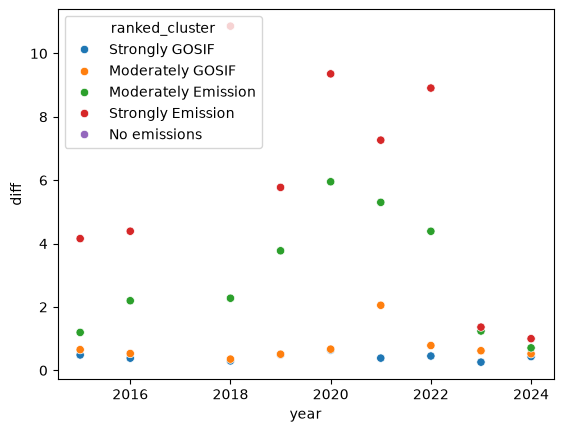

In [48]:
import seaborn as sns

sns.scatterplot(data=cluster_infos, y='diff', x='year',hue='ranked_cluster',palette='tab10')

In [11]:
all_clusters_normalized.groupby(["year","cluster"])[["emission", "growth_rate", "gosif"]].mean()

emission  growth_rate     gosif
year cluster                                 
2015 1        0.000017     0.093969  0.007410
     2        0.789121     0.041932  0.651771
     3        0.043362     0.216679  0.072256
     4        0.189833     0.761303  0.994005
     5        0.492525     0.451431  0.306521
2016 1        0.000005     0.514611  0.007930
     2        0.027134     0.532130  0.153832
     3        0.157926     0.680730  0.082414
     4        0.366370     0.747284  0.993974
     5        0.804914     0.625963  0.531147
2018 1        0.000005     0.272364  0.006167
     2        0.473405     0.008573  0.264286
     3        0.625660     0.263457  0.292799
     4        0.274926     0.127035  0.967936
     5        0.003766     0.000000  0.068958
2019 1        0.000039     0.250616  0.005337
     2        0.888735     0.297639  0.508922
     3        0.400128     0.455755  0.226164
     4        0.153976     0.464667  0.993207
     5        0.017287     0.350749  0.077672
2020 1        0.000024     0.291330  0.006129
     2        1.000000     0.346293  0.560620
     3        0.151017     0.238288  0.093464
     4        0.168066     0.112475  0.870565
     5        0.013762     0.391360  0.117230
2021 1        0.000000     0.109656  0.006094
     2        0.009755     0.358263  0.064700
     3        0.876902     0.359277  0.390081
     4        0.090137     0.054151  0.215892
     5        0.120722     0.127471  1.000000
2022 1        0.000018     0.204807  0.005608
     2        0.007928     0.064346  0.076907
     3        0.976173     0.053267  0.452371
     4        0.222472     0.140093  0.993356
     5        0.211628     0.172153  0.173446
2023 1        0.000003     0.075157  0.003588
     2        0.494179     0.189037  0.221187
     3        0.033912     0.070913  0.082215
     4        0.444632     0.300275  0.941931
     5        0.551935     0.034980  0.584978
2024 1        0.000069     0.666753  0.000000
     2        0.603066     0.792851  0.932187
     3        0.278853     0.615171  0.225886
     4        0.602227     1.000000  0.660151
     5        0.148805     0.820649  0.099948

In [ ]:
# ── 4. Map to your point-level data ──────────────────────────────────────────
df = pd.read_csv(
    r"C:\Users\darja\Complexity72h\complexity72_2026\clustering\kmeans_classified_points_all_years.csv"
 )

dfs = []
for year in all_clusters_normalized["year"].unique():
    df_i = df[["lat", "lon", f"kmeans_cluster_{year}"]].rename(columns={f"kmeans_cluster_{year}": "cluster"})
    acn_i = all_clusters_normalized[all_clusters_normalized["year"]==year][["cluster", "emission", "gosif","growth_rate"]]
    df_i = df_i.merge(acn_i, left_on=f"cluster", right_on="cluster", how="left", validate="many_to_one")

    df_i.to_csv(f"C:\\Users\\darja\\Complexity72h\\complexity72_2026\\clustering\\for_plots\\cluster_info_{year}.csv", index=False)


# 2D - only Emissions and Gosif

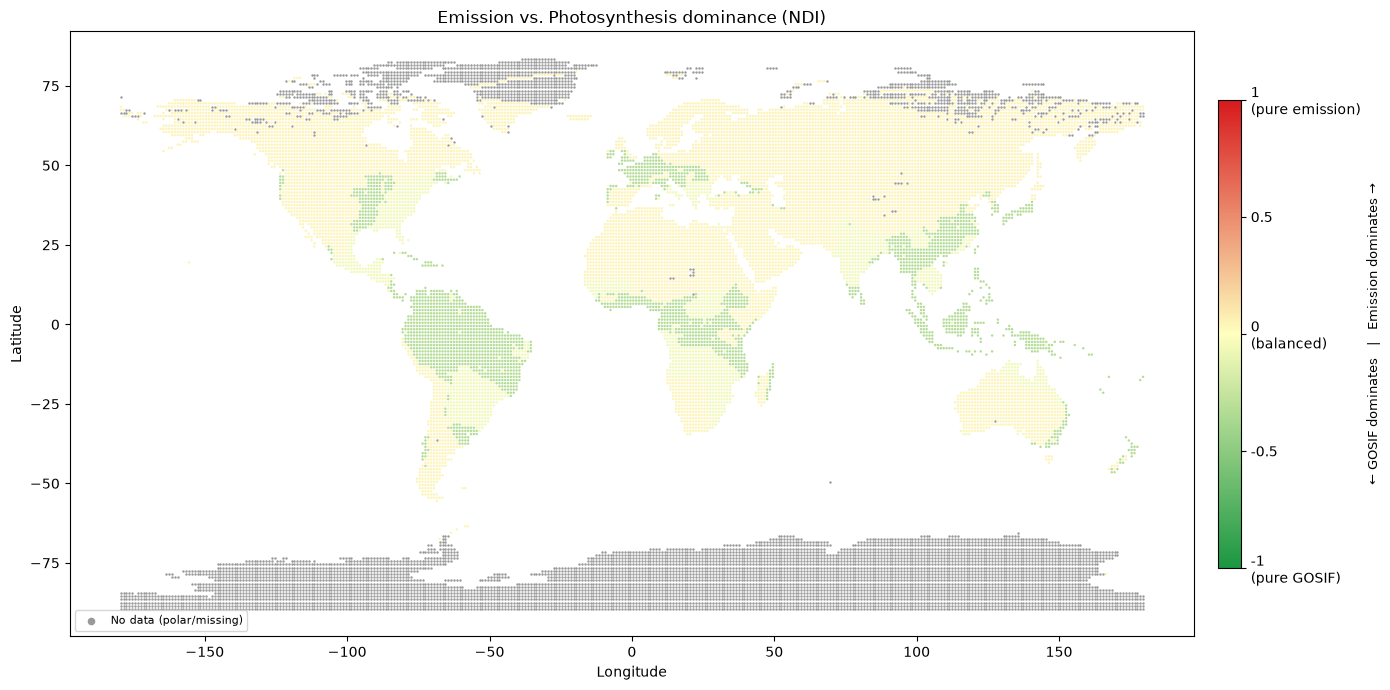

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable

# ── 0. Load your data ─────────────────────────────────────────────────────────
# df = pd.read_csv("your_year.csv")
# For illustration:
# df has columns: lat, lon, cluster, emission, gosif, growth_rate

# ── 1. Define the "near-zero" threshold for NaN masking ──────────────────────
ZERO_THRESH = 1e-4  # tune this — points where both emission AND gosif < this → gray
df = df_i
mask_missing = (df['emission'].abs() < ZERO_THRESH) & (df['gosif'].abs() < ZERO_THRESH)

# ── 2. Compute the signal ─────────────────────────────────────────────────────

# Option A: simple difference
df['signal_diff'] = df['emission'] - df['gosif']

# Option B: normalized difference index (recommended)
denom = df['emission'] + df['gosif']
df['signal_ndi'] = np.where(
    denom < ZERO_THRESH,
    np.nan,                                          # avoid division by zero
    (df['emission'] - df['gosif']) / denom
)

# Choose one:
signal_col = 'signal_diff'   # or 'signal_diff'

# ── 3. Build the colormap ─────────────────────────────────────────────────────
# Green (gosif dominates) ← white (balanced) → Red (emission dominates)
cmap_diverging = mcolors.LinearSegmentedColormap.from_list(
    "green_yellow_red",
    colors=["#1a9641", "#ffffbf", "#d7191c"],  # colorbrewer diverging, yellow midpoint
    N=512
)

# ── 4. Normalize signal to [0, 1] for the colormap ───────────────────────────
# signal range is [-1, 1] for NDI, [-1, 1] for diff too
norm = mcolors.TwoSlopeNorm(vmin=-1.0, vcenter=0.0, vmax=1.0)

# ── 5. Assign colors ──────────────────────────────────────────────────────────
signal_values = df[signal_col].values.copy()
signal_values[mask_missing] = np.nan  # force missing to NaN

# Map finite values through colormap
colors_rgba = np.full((len(df), 4), np.nan)

finite_mask = ~np.isnan(signal_values)
colors_rgba[finite_mask] = cmap_diverging(norm(signal_values[finite_mask]))

# Gray for missing/polar points
GRAY = np.array([0.6, 0.6, 0.6, 1.0])
colors_rgba[mask_missing] = GRAY

# ── 6. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Plot missing (gray) first so they don't cover valid data
ax.scatter(
    df.loc[mask_missing, 'lon'],
    df.loc[mask_missing, 'lat'],
    c=[GRAY], s=3, linewidths=0, rasterized=True, label='No data'
)

# Plot valid points
valid = ~mask_missing & finite_mask
ax.scatter(
    df.loc[valid, 'lon'],
    df.loc[valid, 'lat'],
    c=colors_rgba[valid],
    s=3, linewidths=0, rasterized=True, alpha=1
)

# ── 7. Colorbar ───────────────────────────────────────────────────────────────
sm = ScalarMappable(cmap=cmap_diverging, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.02)
cbar.set_label("← GOSIF dominates   |   Emission dominates →", fontsize=9)
cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
cbar.set_ticklabels(['-1\n(pure GOSIF)', '-0.5', '0\n(balanced)', '0.5', '1\n(pure emission)'])

# Gray patch in legend
gray_patch = plt.scatter([], [], c=[GRAY], s=20, label='No data (polar/missing)')
ax.legend(handles=[gray_patch], loc='lower left', fontsize=8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Emission vs. Photosynthesis dominance (NDI)")
plt.tight_layout()
plt.savefig("emission_gosif_map.pdf", dpi=150, bbox_inches='tight')
plt.show()